In [1]:
from quantum_function import *

# Entanglement of a pair of quantum emitters via Jz

### Ideal case $ \eta_1 = \eta_2 = 1$

In [29]:
gamma = 1             # Atom decay rate
T_1 = 1 / gamma  # time constant for the decay

times = np.array(np.arange(0, 10*T_1, 0.01*T_1)) # time vector


#my_initial_states = [piqs.css(2, x= np.pi/theta, basis = "uncoupled", coordinates="polar") for theta in [1,2,3,4,6]]
my_name_states = [f"css_theta_{theta}" for theta in [1,2,3,4,6]]

my_initial_states = [css_2(np.pi/my_theta, 0) for my_theta in [1,2,3,4,6]]

#Creo dict di dataframe per ogni stato iniziale
photodetection_dfs = {}

#theo_curves = [
    #(1-np.exp(-gamma * times)),
    #(1-np.exp(-2*gamma * times)),
    #(1-np.exp(-2*gamma * times)),
    #(1-np.exp(-2*gamma * times)),
#]

ntraj = 100 # number of trajectories

# solve the master equation using montecarlo equation (photodetection) for every intial state
for name_state,state in zip(my_name_states, my_initial_states):
    my_photodetection = mcsolve(
        H_free, state, times,
        c_ops = [
        np.sqrt(gamma / 2) * (sigma_z_1 + sigma_z_2)/2,
        np.sqrt(gamma / 2) * (sigma_z_1 - sigma_z_2)/2
        ],
        e_ops=[spin_squeezing_KU_solver],
        ntraj=ntraj,
        options={"keep_runs_results": True, "map":"parallel"}, #Necessary to create the keep the e_ops results for each trajectory
    )

    photodetection_dfs[f"{name_state}"] = pd.DataFrame(my_photodetection.expect[0].T, columns=[f"Traj_{i+1}" for i in range(ntraj)])
    photodetection_dfs[f"{name_state}"].index = np.arange(1, photodetection_dfs[f"{name_state}"].shape[0]+1)
    photodetection_dfs[f"{name_state}"].index.name = "Step"
    photodetection_dfs[f"{name_state}"]['mean'] = photodetection_dfs[f"{name_state}"].mean(axis=1)


Total run time:  31.53s


BrokenProcessPool: A process in the process pool was terminated abruptly while the future was running or pending.

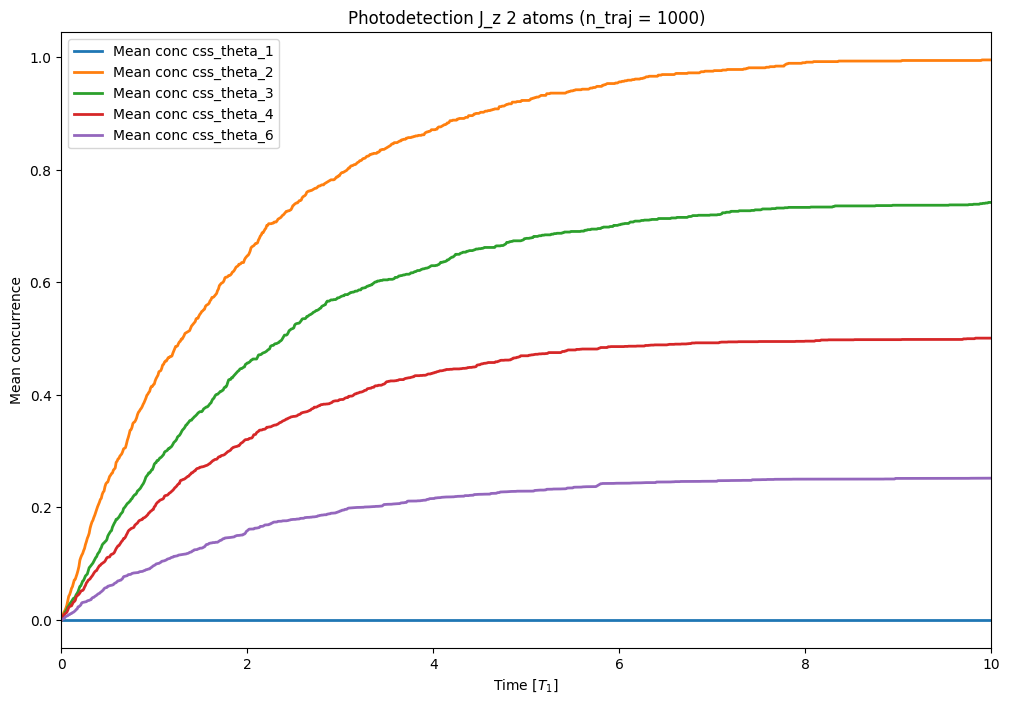

In [12]:
plt.figure(figsize=(12,8))

theo_curves = [(1-np.exp(-2*gamma * times))*np.sin(np.pi/(2*theta)) for theta in [1,2,3,4,6]]

for state,theory in zip(my_name_states, theo_curves):
    line_sim, = plt.plot(times/T_1, photodetection_dfs[f"{state}"]['mean'], label=f"Mean conc {state}", linewidth=2)
    #plt.plot(times/T_1, theory, '--', label=f"Theo conc", color=line_sim.get_color(), alpha=0.5, linewidth=2)

plt.xlim(0, 10)
plt.xlabel(r"Time [$T_1$]")
plt.ylabel("Mean concurrence")
plt.title(f"Photodetection J_z 2 atoms (n_traj = {ntraj})")
plt.legend()
plt.show()

In [13]:
gamma = 1             # Atom decay rate
T_1 = 1 / gamma  # time constant for the decay

times = np.array(np.arange(0, 5*T_1, 0.001*T_1)) # time vector


my_name_states = ["ee","psi_plus","phi_plus"]

my_initial_states = [ee, psi_plus, phi_plus]

#Creo dict di dataframe per ogni stato iniziale
photodetection_dfs = {}

ntraj = 100 # number of trajectories

# solve the master equation using montecarlo equation (photodetection) for every intial state
for name_state,state in zip(my_name_states, my_initial_states):
    my_photodetection = mcsolve(
        H_free, state, times,
        c_ops = [
        np.sqrt(gamma / 2) * (sigma_z_1 + sigma_z_2)/2,
        np.sqrt(gamma / 2) * (sigma_z_1 - sigma_z_2)/2
        ],
        e_ops=[concurrence_for_solver_general],
        ntraj=ntraj,
        options={"keep_runs_results": True, "map":"parallel"}, #Necessary to create the keep the e_ops results for each trajectory
    )

    photodetection_dfs[f"{name_state}"] = pd.DataFrame(my_photodetection.expect[0].T, columns=[f"Traj_{i+1}" for i in range(ntraj)])
    photodetection_dfs[f"{name_state}"].index = np.arange(1, photodetection_dfs[f"{name_state}"].shape[0]+1)
    photodetection_dfs[f"{name_state}"].index.name = "Step"
    photodetection_dfs[f"{name_state}"]['mean'] = photodetection_dfs[f"{name_state}"].mean(axis=1)


10.0%. Run time:   8.76s. Est. time left: 00:00:01:18
20.0%. Run time:   9.19s. Est. time left: 00:00:00:36
30.0%. Run time:   9.72s. Est. time left: 00:00:00:22
40.0%. Run time:  10.12s. Est. time left: 00:00:00:15
50.0%. Run time:  10.54s. Est. time left: 00:00:00:10
60.0%. Run time:  10.96s. Est. time left: 00:00:00:07
70.0%. Run time:  11.40s. Est. time left: 00:00:00:04
80.0%. Run time:  11.89s. Est. time left: 00:00:00:02
90.0%. Run time:  12.34s. Est. time left: 00:00:00:01
100.0%. Run time:  12.71s. Est. time left: 00:00:00:00
Total run time:  13.96s
10.0%. Run time:   8.25s. Est. time left: 00:00:01:14
20.0%. Run time:   8.74s. Est. time left: 00:00:00:34
30.0%. Run time:   9.19s. Est. time left: 00:00:00:21
40.0%. Run time:   9.70s. Est. time left: 00:00:00:14
50.0%. Run time:  10.26s. Est. time left: 00:00:00:10
60.0%. Run time:  10.76s. Est. time left: 00:00:00:07
70.0%. Run time:  11.19s. Est. time left: 00:00:00:04
80.0%. Run time:  11.66s. Est. time left: 00:00:00:02
90.

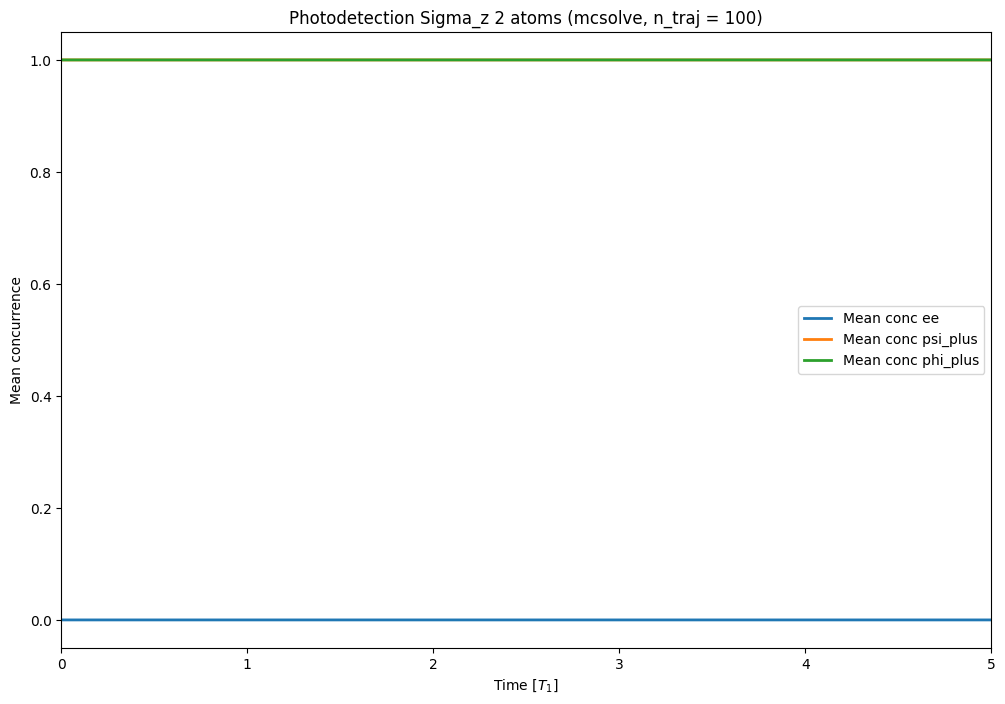

In [14]:
plt.figure(figsize=(12,8))

theo_curves = [(1-np.exp(-2*gamma * times))*np.sin(np.pi/(2*theta)) for theta in [1,2,3,4,6]]

for state,theory in zip(my_name_states, theo_curves):
    line_sim, = plt.plot(times/T_1, photodetection_dfs[f"{state}"]['mean'], label=f"Mean conc {state}", linewidth=2)
    #plt.plot(times/T_1, theory, '--', label=f"Theo conc", color=line_sim.get_color(), alpha=0.5, linewidth=2)

plt.xlim(0, 5)
plt.xlabel(r"Time [$T_1$]")
plt.ylabel("Mean concurrence")
plt.title(f"Photodetection Sigma_z 2 atoms (mcsolve, n_traj = {ntraj})")
plt.legend()
plt.show()

## Css states

$|\theta, \phi\rangle = \bigotimes_{i=1}^N \left( \cos\frac{\theta}{2}\,|0\rangle_i + e^{i\phi}\sin\frac{\theta}{2}\,|1\rangle_i \right)$

x=theta se uso coordinate polari

In [ ]:
"""
def css_2(theta, phi):
    if theta == np.pi: #State |11>
        return tensor(basis(2,0), basis(2,0))
    
    elif theta == 0: #State |00>
        return tensor(basis(2,1), basis(2,1))
    
    single_qubit = (np.sin(theta/2) * basis(2,0) + np.exp(1j*phi) * np.cos(theta/2) * basis(2,1))
    return tensor(single_qubit, single_qubit)

css_2(np.pi/2, 0)
"""

Quantum object: dims=[[2, 2], [1]], shape=(4, 1), type='ket', dtype=Dense
Qobj data =
[[0.5]
 [0.5]
 [0.5]
 [0.5]]

In [ ]:
gamma = 1        # Atom decay rate
T_1 = 1 / gamma  # time constant for the decay

times = np.array(np.arange(0, 5*T_1, 0.001*T_1)) # time vector

my_name_states = [f"css_theta=pi/{angle}" for angle in [1,2,3,4,6]]
#my_initial_states = [css_2(theta=np.pi/angle, phi=0) for angle in [1,2,3,4,6]] 

#Now I have to use the css from piqs because I need the density matrix
#my_initial_states = [piqs.css(2, x= np.pi/theta, basis = "uncoupled", coordinates="polar") for theta in [1,2,3,4,6]] #|11>, |++>, ..., ..., ..., 

my_eta = [1, 0.9, 0.7, 0.5] # detection efficiency

#Dict of dataframe for each initial state
photodetection_dfs = {}

ntraj = 100 # number of trajectories

# solve the master equation using montecarlo equation (photodetection) for every intial state
for eta in my_eta:
    my_photodetection = smesolve(
        H_free, state, times,

        c_ops = [
        np.sqrt(gamma*eta / 2) * (sigma_z_1 + sigma_z_2),
        np.sqrt(gamma*eta / 2) * (sigma_z_1 - sigma_z_2)
        ],

        sc_ops = [
        np.sqrt(gamma*(1-eta) / 2) * (sigma_minus_1),
        np.sqrt(gamma*(1-eta) / 2) * (sigma_minus_2)
        ],

        e_ops=[concurrence_for_solver_general],
        ntraj=ntraj,
        options={"keep_runs_results": True, "map":"parallel"}, #Necessary to create the keep the e_ops results for each trajectory
    )

    photodetection_dfs[f"{name_state}"] = pd.DataFrame(my_photodetection.expect[0].T, columns=[f"Traj_{i+1}" for i in range(ntraj)])
    photodetection_dfs[f"{name_state}"].index = np.arange(1, photodetection_dfs[f"{name_state}"].shape[0]+1)
    photodetection_dfs[f"{name_state}"].index.name = "Step"
    photodetection_dfs[f"{name_state}"]['mean'] = photodetection_dfs[f"{name_state}"].mean(axis=1)


In [35]:
(sigma_z_1+sigma_z_2)*(sigma_z_1+sigma_z_2)

Quantum object: dims=[[2, 2], [2, 2]], shape=(4, 4), type='oper', dtype=CSR, isherm=True
Qobj data =
[[4. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 4.]]

# Spin squeezing

In [2]:
#=================================================================================================================================
# //-- SPIN SQUEEZING --// =======================================================================================================
#=================================================================================================================================

J_x = 0.5 * (tensor(sigmax(), I_2) + tensor(I_2, sigmax()))
J_y = 0.5 * (tensor(sigmay(), I_2) + tensor(I_2, sigmay()))
J_z = 0.5 * (tensor(sigmaz(), I_2) + tensor(I_2, sigmaz())) 

val_sus = 0

def css_2(theta, phi):
    single_qubit = (np.sin(theta/2) * basis(2,0) + np.exp(1j*phi) * np.cos(theta/2) * basis(2,1))
    return tensor(single_qubit, single_qubit)

def round_if_close(val, target=1.0, atol=1e-12):
    """
    Se `val` è numericamente vicino a `target` entro `atol`, restituisce `target`.
    Altrimenti restituisce `val` invariato.
    """
    
    if np.isclose(val, target, atol=atol):
        return target
    return val

def eval_spin_components(state):
    return expect(J_x, state), expect(J_y, state), expect(J_z, state)

#Using the rounding to 1
def eval_variances(state):
    return round_if_close(variance(J_x, state)), round_if_close(variance(J_y, state)), round_if_close(variance(J_z, state))

def eval_J_norm(state):
    return np.sqrt(np.abs(expect(J_x, state))**2 + np.abs(expect(J_y, state))**2 + np.abs(expect(J_z, state))**2)



def compute_spin_squeezing_angles(rho):
    """Calcola θ e φ a partire dai valori medi di J"""
    
    # valori medi
    Jx_exp, Jy_exp, Jz_exp = eval_spin_components(rho)
    J_norm = eval_J_norm(rho)  
    
    #If J_norm==0, as Bell states
    if np.abs(J_norm)==0:
        return val_sus, val_sus

    else:
        theta = np.arccos(Jz_exp / J_norm)

        if np.sin(theta)==0:
            return theta, 0

        cosphi = Jx_exp / (J_norm * np.sin(theta))
        cosphi = np.clip(cosphi, -1.0, 1.0)  # stabilità numerica
        if Jy_exp > 0:
            phi = np.arccos(cosphi)
        else:
            phi = 2*np.pi - np.arccos(cosphi)
    
    return theta, phi



def Jn1_Jn_2(rho, theta, phi):
    """Calcola J_n1 e J_n2 a partire da θ e φ"""
    
    # versori
    n1 = np.array([-np.sin(phi), np.cos(phi), 0.0])
    n2 = np.array([np.cos(theta)*np.cos(phi), np.cos(theta)*np.sin(phi), -np.sin(theta)])
    
    # operatori
    Jn1 = n1[0]*J_x + n1[1]*J_y + n1[2]*J_z
    Jn2 = n2[0]*J_x + n2[1]*J_y + n2[2]*J_z
    
    return Jn1, Jn2



def spin_squeezing_KU(rho):
    """Calcola il parametro di spin squeezing secondo Kitagawa-Ueda"""
    
    # calcolo θ e φ
    theta, phi = compute_spin_squeezing_angles(rho)

    if theta==val_sus and phi==val_sus:
        return val_sus
    
    # calcolo J_n1 e J_n2
    Jn1, Jn2 = Jn1_Jn_2(rho, theta, phi)
    
    #xi_sq = (2/N)*(expect(Jn1**2+Jn2**2, rho)-np.sqrt((expect(Jn1**2-Jn2**2, rho))**2 + (expect(Jn1*Jn2+Jn2*Jn1, rho))**2))/eval_J_norm(rho) by autocompletion
    xi_sq = (expect(Jn1**2+Jn2**2, rho)-np.sqrt((expect(Jn1**2-Jn2**2, rho))**2 + (expect(Jn1*Jn2+Jn2*Jn1, rho))**2))
    return np.clip(xi_sq,0,1) # clip to avoid numerical issues

def spin_squeezing_KU_solver(t, rho):
    """Calcola il parametro di spin squeezing secondo Kitagawa-Ueda"""
    
    # calcolo θ e φ
    theta, phi = compute_spin_squeezing_angles(rho)
    
    if theta==val_sus and phi==val_sus:
        return val_sus
    
    # calcolo J_n1 e J_n2
    Jn1, Jn2 = Jn1_Jn_2(rho, theta, phi)
    
    #xi_sq = (2/N)*(expect(Jn1**2+Jn2**2, rho)-np.sqrt((expect(Jn1**2-Jn2**2, rho))**2 + (expect(Jn1*Jn2+Jn2*Jn1, rho))**2))/eval_J_norm(rho) by autocompletion
    xi_sq = (expect(Jn1**2+Jn2**2, rho)-np.sqrt((expect(Jn1**2-Jn2**2, rho))**2 + (expect(Jn1*Jn2+Jn2*Jn1, rho))**2))
    return np.clip(xi_sq,0,1) # clip to avoid numerical issues

def peres_horodecki_test(rho, tol=1e-10):
    """
    Implementazione del test di Peres–Horodecki per 2 qubit.
    Restituisce (bool, autovalori).
    - True: lo stato è entangled
    - False: lo stato è separabile
    """

    if rho.isket==True:
        rho = ket2dm(rho)
        
    rho_pt = qutip.partial_transpose(rho, mask=[0,1])  # trasposizione parziale su secondo qubit
    eigvals = rho_pt.eigenenergies()
    entangled = np.any(eigvals < -tol)
    return int(not entangled)


def peres_horodecki_test_solver(t, rho):
    """
    Implementazione del test di Peres–Horodecki per 2 qubit.
    Restituisce (bool, autovalori).
    - True: lo stato è entangled
    - False: lo stato è separabile
    """

    if rho.isket==True:
        rho = ket2dm(rho)
        
    rho_pt = qutip.partial_transpose(rho, mask=[0,1])  # trasposizione parziale su secondo qubit
    eigvals = rho_pt.eigenenergies()
    entangled = np.any(eigvals < -1e-10)
    return int(not entangled)

def spin_squeezing_W(rho, N):
    return spin_squeezing_KU(rho)*(N/(2*eval_J_norm(rho)))**2


Testo i due parametri di spin squeezing su |++>, risultano entrambi 1

In [38]:
spin_squeezing_W(css_2(np.pi/2, 0), 2)
#spin_squeezing_KU(css_2(np.pi/2, 0))

np.float64(0.9999999999999991)

In [31]:
gamma = 1        # Atom decay rate
T_1 = 1 / gamma  # time constant for the decay

times = np.array(np.arange(0, 10*T_1, 0.01*T_1)) # time vector

my_name_states = ["ee","++","css_theta=pi/3","css_theta=pi/4","css_theta=pi/6"]

my_initial_states = [
    ee,
    css_2(np.pi/2, phi=0),
    css_2(np.pi/3, phi=0),
    css_2(np.pi/4, phi=0),
    css_2(np.pi/6, phi=0)
]

#Creo dict di dataframe per ogni stato iniziale
photodetection_dfs = {}

ntraj = 100 # number of trajectories

# solve the master equation using montecarlo equation (photodetection) for every intial state
for name_state,state in zip(my_name_states, my_initial_states):
    my_photodetection = mcsolve(
        H_free, state, times,
        c_ops = [
        np.sqrt(gamma / 2) * (sigma_z_1 + sigma_z_2)/2,
        np.sqrt(gamma / 2) * (sigma_z_1 - sigma_z_2)/2
        ],
        e_ops=[spin_squeezing_KU_solver],
        ntraj=ntraj,
        options={"keep_runs_results": True}, #Necessary to create the keep the e_ops results for each trajectory
    )

    photodetection_dfs[f"{name_state}"] = pd.DataFrame(my_photodetection.expect[0].T, columns=[f"Traj_{i+1}" for i in range(ntraj)])
    photodetection_dfs[f"{name_state}"].index = np.arange(1, photodetection_dfs[f"{name_state}"].shape[0]+1)
    photodetection_dfs[f"{name_state}"].index.name = "Step"
    photodetection_dfs[f"{name_state}"]['mean'] = photodetection_dfs[f"{name_state}"].mean(axis=1)


10.0%. Run time:   0.45s. Est. time left: 00:00:00:04
20.0%. Run time:   0.92s. Est. time left: 00:00:00:03
30.0%. Run time:   1.44s. Est. time left: 00:00:00:03
40.0%. Run time:   1.96s. Est. time left: 00:00:00:02
50.0%. Run time:   2.47s. Est. time left: 00:00:00:02
60.0%. Run time:   2.96s. Est. time left: 00:00:00:01
70.0%. Run time:   3.39s. Est. time left: 00:00:00:01
80.0%. Run time:   3.83s. Est. time left: 00:00:00:00
90.0%. Run time:   4.31s. Est. time left: 00:00:00:00
100.0%. Run time:   4.77s. Est. time left: 00:00:00:00
Total run time:   4.83s
10.0%. Run time:   0.88s. Est. time left: 00:00:00:07
20.0%. Run time:   1.86s. Est. time left: 00:00:00:07
30.0%. Run time:   3.12s. Est. time left: 00:00:00:07
40.0%. Run time:   4.10s. Est. time left: 00:00:00:06
50.0%. Run time:   4.93s. Est. time left: 00:00:00:04
60.0%. Run time:   5.70s. Est. time left: 00:00:00:03
70.0%. Run time:   6.98s. Est. time left: 00:00:00:02
80.0%. Run time:   7.76s. Est. time left: 00:00:00:01
90.

In [29]:
#photodetection_dfs["css_theta_3"].head(20)

KU_spin squeezing è 0 per |ee> perché autostato di Jz. La varianza su un asse perpendicolare, ossia sul piano x-y è 0

In [ ]:
#my_state = css_2(np.pi/2, 0)
peres = [peres_horodecki_test(state) for state in my_initial_states]
KU = [spin_squeezing_KU(state) for state in my_initial_states]

peres, KU

([1, 1, 1, 1, 1],
 [0,
  np.float64(1.0),
  np.float64(1.0),
  np.float64(0.9999999999999999),
  np.float64(1.0)])

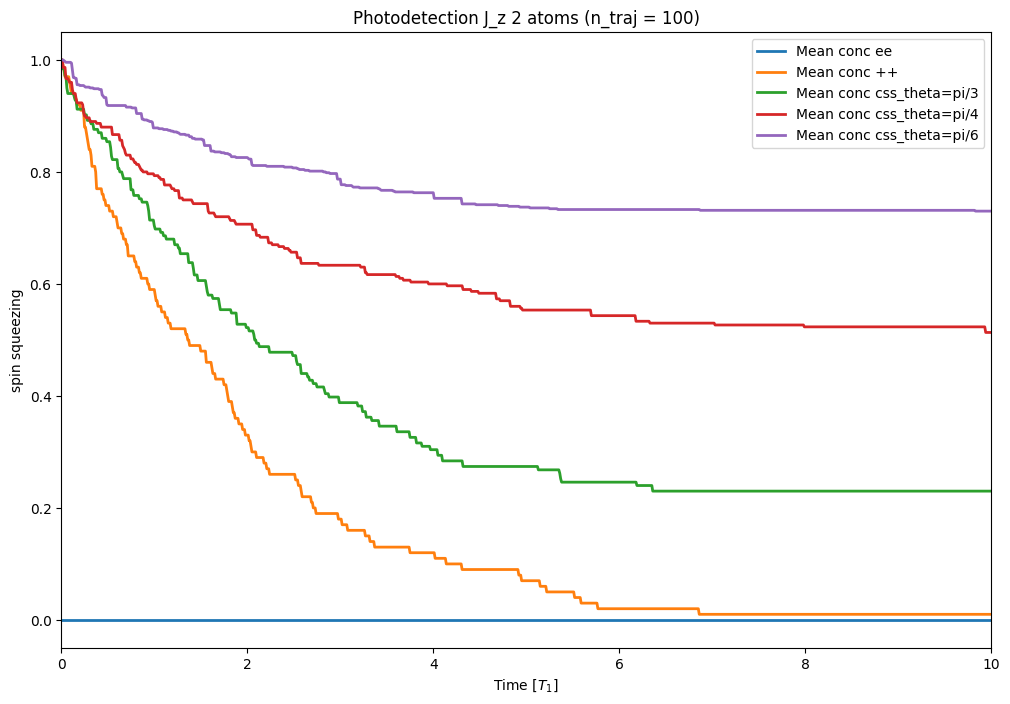

In [23]:
plt.figure(figsize=(12,8))

theo_curves = [(1-np.exp(-2*gamma * times))*np.sin(np.pi/(2*theta)) for theta in [1,2,3,4,6]]

for state,theory in zip(my_name_states, theo_curves):
    line_sim, = plt.plot(times/T_1, photodetection_dfs[f"{state}"]['mean'], label=f"Mean conc {state}", linewidth=2)
    #plt.plot(times/T_1, theory, '--', label=f"Theo conc", color=line_sim.get_color(), alpha=0.5, linewidth=2)

plt.xlim(0, 10)
plt.xlabel(r"Time [$T_1$]")
plt.ylabel("spin squeezing")
plt.title(f"Photodetection J_z 2 atoms (n_traj = {ntraj})")
plt.legend()
plt.show()

## Usando Peres-Horodecki, 1 se separabile e 0 entangled (come spin squeezing)

In [26]:
gamma = 1        # Atom decay rate
T_1 = 1 / gamma  # time constant for the decay

times = np.array(np.arange(0, 10*T_1, 0.01*T_1)) # time vector

#Creo dict di dataframe per ogni stato iniziale
photodetection_dfs = {}

ntraj = 500 # number of trajectories

# solve the master equation using montecarlo equation (photodetection) for every intial state
for name_state,state in zip(my_name_states, my_initial_states):
    my_photodetection = mcsolve(
        H_free, state, times,
        c_ops = [
        np.sqrt(gamma / 2) * (sigma_z_1 + sigma_z_2)/2,
        np.sqrt(gamma / 2) * (sigma_z_1 - sigma_z_2)/2
        ],
        e_ops=[peres_horodecki_test_solver],
        ntraj=ntraj,
        options={"keep_runs_results": True}, #Necessary to create the keep the e_ops results for each trajectory
    )

    photodetection_dfs[f"{name_state}"] = pd.DataFrame(my_photodetection.expect[0].T, columns=[f"Traj_{i+1}" for i in range(ntraj)])
    photodetection_dfs[f"{name_state}"].index = np.arange(1, photodetection_dfs[f"{name_state}"].shape[0]+1)
    photodetection_dfs[f"{name_state}"].index.name = "Step"
    photodetection_dfs[f"{name_state}"]['mean'] = photodetection_dfs[f"{name_state}"].mean(axis=1)


10.0%. Run time:   9.83s. Est. time left: 00:00:01:28
20.0%. Run time:  19.21s. Est. time left: 00:00:01:16
30.0%. Run time:  28.63s. Est. time left: 00:00:01:06
40.0%. Run time:  38.04s. Est. time left: 00:00:00:57
50.0%. Run time:  47.35s. Est. time left: 00:00:00:47
60.0%. Run time:  57.65s. Est. time left: 00:00:00:38
70.0%. Run time:  69.72s. Est. time left: 00:00:00:29
80.0%. Run time:  79.38s. Est. time left: 00:00:00:19
90.0%. Run time:  88.73s. Est. time left: 00:00:00:09
100.0%. Run time:  98.19s. Est. time left: 00:00:00:00
Total run time:  98.39s
10.0%. Run time:   9.63s. Est. time left: 00:00:01:26
20.0%. Run time:  19.45s. Est. time left: 00:00:01:17
30.0%. Run time:  29.85s. Est. time left: 00:00:01:09
40.0%. Run time:  41.38s. Est. time left: 00:00:01:02
50.0%. Run time:  52.95s. Est. time left: 00:00:00:52
60.0%. Run time:  63.28s. Est. time left: 00:00:00:42
70.0%. Run time:  74.38s. Est. time left: 00:00:00:31
80.0%. Run time:  84.77s. Est. time left: 00:00:00:21
90.

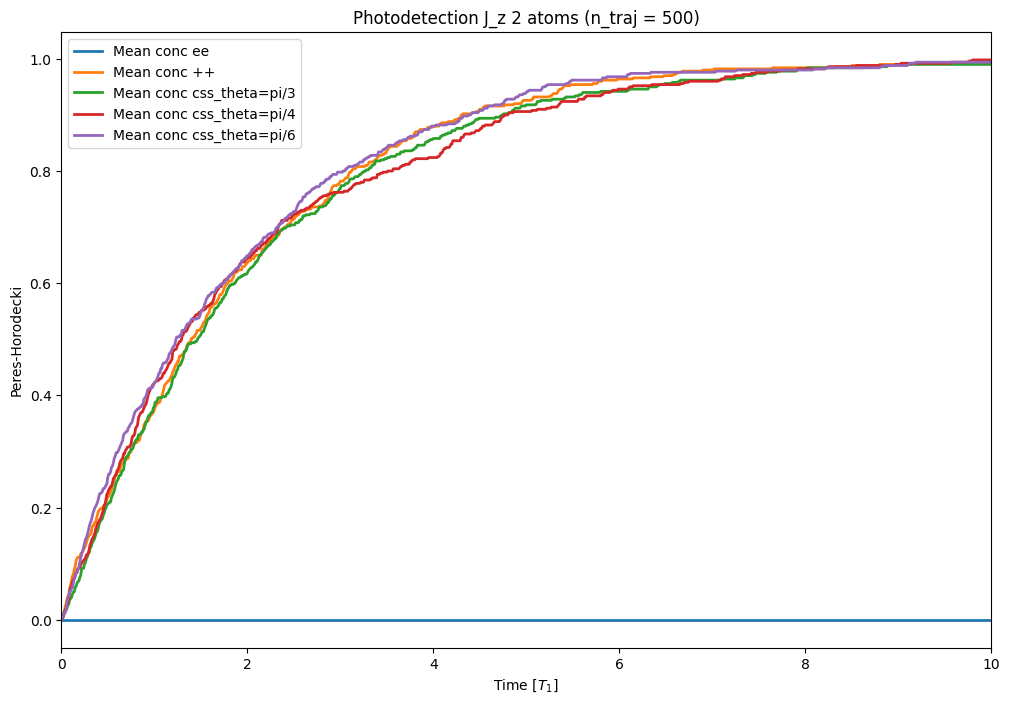

In [27]:
plt.figure(figsize=(12,8))

theo_curves = [(1-np.exp(-2*gamma * times))*np.sin(np.pi/(2*theta)) for theta in [1,2,3,4,6]]

for state,theory in zip(my_name_states, theo_curves):
    line_sim, = plt.plot(times/T_1, 1-abs(photodetection_dfs[f"{state}"]['mean']), label=f"Mean conc {state}", linewidth=2)
    #plt.plot(times/T_1, theory, '--', label=f"Theo conc", color=line_sim.get_color(), alpha=0.5, linewidth=2)

plt.xlim(0, 10)
plt.xlabel(r"Time [$T_1$]")
plt.ylabel("Peres-Horodecki")
plt.title(f"Photodetection J_z 2 atoms (n_traj = {ntraj})")
plt.legend()
plt.show()

Tranne per lo stato |ee>, gli altri stati tendono dopo 10*T1 ad essere entangled!

# Test fidelity

Voglio testare la fidelity tra gli stati asintotici e gli stati di Bell, per capire in quale di essi finisco.
Prima vedo qual'è la distanza tra di loro e tra di loro con gli stati di partenza

In [5]:
qutip.fidelity(ee, eg)

np.float64(0.0)

Se gli stati sono entrambi puri, la fidelity si riduce all'overlap! Quindi testato su stati diversi ma della stessa base risulta 0.

Vale 1 SE E SOLO SE i due stati in input sono uguali!

In [6]:
fidelity(eg, psi_plus)

np.float64(0.7071067811865475)

In [7]:
def fidelity_phi_plus(rho):
    return fidelity(rho, phi_plus)

def fidelity_phi_plus_solver(t, rho):
    return fidelity(rho, phi_plus)

def fidelity_phi_minus_solver(t, rho):
    return fidelity(rho, phi_minus)

def fidelity_psi_plus_solver(t, rho):
    return fidelity(rho, psi_plus)

def fidelity_psi_minus_solver(t, rho):
    return fidelity(rho, psi_minus)

fidelity_ops = [
    fidelity_phi_plus_solver,
    fidelity_phi_minus_solver,
    fidelity_psi_plus_solver,
    fidelity_psi_minus_solver]

In [66]:
gamma = 1        # Atom decay rate
T_1 = 1 / gamma  # time constant for the decay

times = np.array(np.arange(0, 10*T_1, 0.01*T_1)) # time vector

ntraj = 500 # number of trajectories

my_name_states = ["ee","++","css_theta=pi/3"]

my_initial_states = [
    ee,
    css_2(np.pi/2, phi=0),
    css_2(np.pi/3, phi=0)
]

fidelity_dfs = {}

# solve the master equation using montecarlo equation (photodetection) for every intial state
for name_state,state in zip(my_name_states, my_initial_states):
    my_photodetection = mcsolve(
        H_free, state, times,
        c_ops = [
        np.sqrt(gamma / 2) * (sigma_z_1 + sigma_z_2)/2,
        np.sqrt(gamma / 2) * (sigma_z_1 - sigma_z_2)/2
        ],
        e_ops=fidelity_ops,
        ntraj=ntraj,
        options={"keep_runs_results": True}, #Necessary to create the keep the e_ops results for each trajectory
    )
    
    # raccolgo i risultati finali in una lista di liste
    data = []
    for traj_idx in range(ntraj):
        final_vals = [my_photodetection.expect[i][traj_idx][-1] for i in range(len(fidelity_ops))]
        data.append(final_vals)

    # creo il DataFrame
    fidelity_dfs[f"{name_state}"] = pd.DataFrame(
        data,
        columns=[f.__name__ for f in fidelity_ops],  # i nomi: psi_minus, psi_plus, ...
        index=[f"Traj_{i+1}" for i in range(ntraj)]
        )

10.0%. Run time:   2.15s. Est. time left: 00:00:00:19
20.0%. Run time:   4.52s. Est. time left: 00:00:00:18
30.0%. Run time:   7.17s. Est. time left: 00:00:00:16
40.0%. Run time:   9.59s. Est. time left: 00:00:00:14
50.0%. Run time:  11.79s. Est. time left: 00:00:00:11
60.0%. Run time:  14.02s. Est. time left: 00:00:00:09
70.0%. Run time:  16.20s. Est. time left: 00:00:00:06
80.0%. Run time:  18.46s. Est. time left: 00:00:00:04
90.0%. Run time:  20.60s. Est. time left: 00:00:00:02
100.0%. Run time:  22.71s. Est. time left: 00:00:00:00
Total run time:  22.76s
10.0%. Run time:   2.29s. Est. time left: 00:00:00:20
20.0%. Run time:   4.69s. Est. time left: 00:00:00:18
30.0%. Run time:   7.20s. Est. time left: 00:00:00:16
40.0%. Run time:   9.41s. Est. time left: 00:00:00:14
50.0%. Run time:  11.73s. Est. time left: 00:00:00:11
60.0%. Run time:  14.00s. Est. time left: 00:00:00:09
70.0%. Run time:  16.65s. Est. time left: 00:00:00:07
80.0%. Run time:  19.18s. Est. time left: 00:00:00:04
90.

In [74]:
for name_state in my_name_states:
    df = fidelity_dfs[f"{name_state}"]
    df["has_one"] = (df> 0.999).any(axis=1)


name_state = "css_theta=pi/3"
count_psi_plus = fidelity_dfs[name_state]['fidelity_psi_plus_solver'].sum()
count_psi_minus = fidelity_dfs[name_state]['fidelity_psi_minus_solver'].sum()
count_phi_plus = fidelity_dfs[name_state]['fidelity_phi_plus_solver'].sum()
count_phi_minus = fidelity_dfs[name_state]['fidelity_phi_minus_solver'].sum()

print("Occorrenze di 1 in psi plus:", count_psi_plus)
print("Occorrenze di 1 in psi minus:", count_psi_minus)
print("Occorrenze di 1 in phi plus:", count_phi_plus)
print("Occorrenze di 1 in phi minus:", count_phi_minus)

fidelity_dfs[name_state]

Occorrenze di 1 in psi plus: 89.83711730708738
Occorrenze di 1 in psi minus: 102.0
Occorrenze di 1 in phi plus: 203.3674383185407
Occorrenze di 1 in phi minus: 211.69826365225998


,fidelity_phi_plus_solver,fidelity_phi_minus_solver,fidelity_psi_plus_solver,fidelity_psi_minus_solver,has_one
Traj_1,0.000000,0.000000,1.0,0.0,True
Traj_2,0.000000,0.000000,1.0,0.0,True
Traj_3,0.447214,0.894427,0.0,0.0,False
Traj_4,0.894427,0.447214,0.0,0.0,False
Traj_5,0.894427,0.447214,0.0,0.0,False
...,...,...,...,...,...
Traj_496,0.000000,0.000000,1.0,0.0,True
Traj_497,0.000000,0.000000,0.0,1.0,True
Traj_498,0.894427,0.447214,0.0,0.0,False
Traj_499,0.000000,0.000000,1.0,0.0,True


array([[<Axes: title={'center': 'fidelity_phi_plus_solver'}>,
        <Axes: title={'center': 'fidelity_phi_minus_solver'}>],
       [<Axes: title={'center': 'fidelity_psi_plus_solver'}>,
        <Axes: title={'center': 'fidelity_psi_minus_solver'}>]],
      dtype=object)

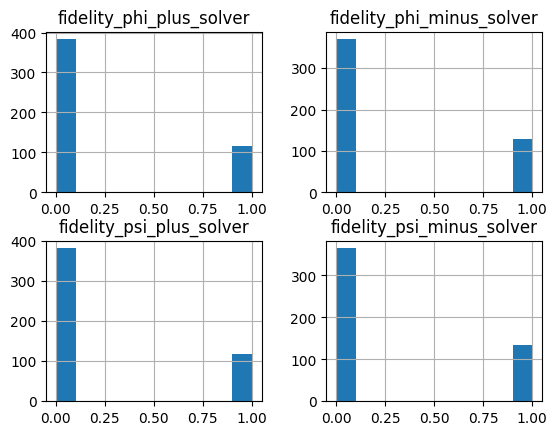

In [76]:
fidelity_dfs["++"].hist()

In [12]:
Sz_1 = sigma_z_1/2
Sz_2 = sigma_z_2/2

c_ops =[np.sqrt(gamma) * ((Sz_1+Sz_2)/np.sqrt(2)), np.sqrt(gamma) * ((Sz_1-Sz_2)/np.sqrt(2))]

# E' giusto, basta provare direttamente con tensor(I_2, I_2)/4 - Sz_1*Sz_2
#Ovviamente c'è prima quello col + e poi quello col -

c_daga_c = [c.dag()*c for c in c_ops]
c_daga_c

[Quantum object: dims=[[2, 2], [2, 2]], shape=(4, 4), type='oper', dtype=CSR, isherm=True
 Qobj data =
 [[50000.     0.     0.     0.]
  [    0.     0.     0.     0.]
  [    0.     0.     0.     0.]
  [    0.     0.     0. 50000.]],
 Quantum object: dims=[[2, 2], [2, 2]], shape=(4, 4), type='oper', dtype=CSR, isherm=True
 Qobj data =
 [[    0.     0.     0.     0.]
  [    0. 50000.     0.     0.]
  [    0.     0. 50000.     0.]
  [    0.     0.     0.     0.]]]

In [21]:
gamma = 1   # Atomic decay rate
T_1 = 1 / gamma  # time constant for the decay
dt = 0.01*T_1    # time step

times = np.array(np.arange(0, 10*T_1, dt)) # time vector

ntraj = 500 # number of trajectories

my_name_states = ["ee","++","css_theta=pi/3", "css_theta=pi/4", "css_theta=pi/6"]

my_initial_states = [
    ee,
    css_2(np.pi/2, phi=0),
    css_2(np.pi/3, phi=0),
    css_2(np.pi/4, phi=0),
    css_2(np.pi/6, phi=0)
]

#IL dt E' IMPORTANTEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEE
#dt = 0.01*T_1
def eval_prob_jump(rho, c_daga_c):

    jump_plus = expect(c_daga_c[0], rho)*dt
    jump_minus = expect(c_daga_c[1], rho)*dt

    return jump_plus, jump_minus, jump_plus+jump_minus

for name, state in zip(my_name_states, my_initial_states):
    print(f"Jump probability for state {name}: {eval_prob_jump(state, c_daga_c)}")

#La loro somma coincide con questo!
print(gamma*dt/2)

Jump probability for state ee: (500.0, 0.0, 500.0)
Jump probability for state ++: (250.00000000000014, 250.00000000000014, 500.0000000000003)
Jump probability for state css_theta=pi/3: (312.50000000000006, 187.49999999999997, 500.0)
Jump probability for state css_theta=pi/4: (375.0, 125.00000000000001, 500.0)
Jump probability for state css_theta=pi/6: (437.50000000000006, 62.499999999999986, 500.00000000000006)
0.005


Fissare epsilon o gamma? Meglio Gamma che è più fisico, legato alla teoria microscopica.
Se gamma tende all'infinito (ossia decay rate alto, quasi istant decay) le prob di jump si azzerano?!?

Devo capire perché i grafici della concurrence variano in base a theta...come mai? La prob. di no jump sembra uguale per qualsiasi CSS, indipendente da theta...
Ho qualche differenza tra decadere nel canale + e in quello -? C'è una qualche ragione di simmetria? Il canale + è simmetrico per scambio 1<->2 mentre il - no.

## Spettro comune di Jz e Sz1 - Sz2 / sqrt(2)

In [34]:
#Partiamo (ri)definendo i due operatori, è importante specificare gamma

gamma = 1   # Atomic decay rate
Sz_1 = sigma_z_1/2
Sz_2 = sigma_z_2/2

c_ops =[np.sqrt(gamma) * ((Sz_1+Sz_2)/np.sqrt(2)), np.sqrt(gamma) * ((Sz_1-Sz_2)/np.sqrt(2))]
c_daga_c = [c.dag()*c for c in c_ops]

# E' giusto, basta provare direttamente con tensor(I_2, I_2)/4 - Sz_1*Sz_2
#Ovviamente c'è prima quello col + e poi quello col -

c_ops

[Quantum object: dims=[[2, 2], [2, 2]], shape=(4, 4), type='oper', dtype=CSR, isherm=True
 Qobj data =
 [[ 0.70710678  0.          0.          0.        ]
  [ 0.          0.          0.          0.        ]
  [ 0.          0.          0.          0.        ]
  [ 0.          0.          0.         -0.70710678]],
 Quantum object: dims=[[2, 2], [2, 2]], shape=(4, 4), type='oper', dtype=CSR, isherm=True
 Qobj data =
 [[ 0.          0.          0.          0.        ]
  [ 0.          0.70710678  0.          0.        ]
  [ 0.          0.         -0.70710678  0.        ]
  [ 0.          0.          0.          0.        ]]]

In [31]:
eigen_c_plus = c_ops[0].eigenstates()
eigen_c_minus = c_ops[1].eigenstates()

In [ ]:
#Autovalore -1/sqrt(2) per |gg>, +1/sqrt(2) per |ee> e 0 per i due stati |eg> e |ge> 
eigen_c_plus

(array([-0.70710678,  0.        ,  0.        ,  0.70710678]),
 array([Quantum object: dims=[[2, 2], [1]], shape=(4, 1), type='ket', dtype=Dense
        Qobj data =
        [[0.]
         [0.]
         [0.]
         [1.]]                                                                   ,
        Quantum object: dims=[[2, 2], [1]], shape=(4, 1), type='ket', dtype=Dense
        Qobj data =
        [[0.]
         [1.]
         [0.]
         [0.]]                                                                   ,
        Quantum object: dims=[[2, 2], [1]], shape=(4, 1), type='ket', dtype=Dense
        Qobj data =
        [[0.]
         [0.]
         [1.]
         [0.]]                                                                   ,
        Quantum object: dims=[[2, 2], [1]], shape=(4, 1), type='ket', dtype=Dense
        Qobj data =
        [[1.]
         [0.]
         [0.]
         [0.]]                                                                   ],
       dtype=object))

In [ ]:
#Autovalore -1/sqrt(2) per |ge>, +1/sqrt(2) per |eg> e 0 per i due stati |ee> e |gg> 
eigen_c_minus

(array([-0.70710678,  0.        ,  0.        ,  0.70710678]),
 array([Quantum object: dims=[[2, 2], [1]], shape=(4, 1), type='ket', dtype=Dense
        Qobj data =
        [[0.]
         [0.]
         [1.]
         [0.]]                                                                   ,
        Quantum object: dims=[[2, 2], [1]], shape=(4, 1), type='ket', dtype=Dense
        Qobj data =
        [[1.]
         [0.]
         [0.]
         [0.]]                                                                   ,
        Quantum object: dims=[[2, 2], [1]], shape=(4, 1), type='ket', dtype=Dense
        Qobj data =
        [[0.]
         [0.]
         [0.]
         [1.]]                                                                   ,
        Quantum object: dims=[[2, 2], [1]], shape=(4, 1), type='ket', dtype=Dense
        Qobj data =
        [[0.]
         [1.]
         [0.]
         [0.]]                                                                   ],
       dtype=object))